## Modelado del sistema con NARX (5 retardos)

En este análisis se emplea un modelo NARX con 5 retardos, lo que implica un mayor nivel de memoria del sistema. Se comparan un modelo lineal y un modelo no lineal (MLP) para evaluar si el aumento de información mejora la capacidad predictiva.

El objetivo es analizar si el incremento de retardos permite capturar mejor la dinámica del sistema o si introduce problemas como sobreajuste.

Shape: (29988, 29)
MSE lineal: 0.010337162093504203
MSE MLP: 0.009475379628134441


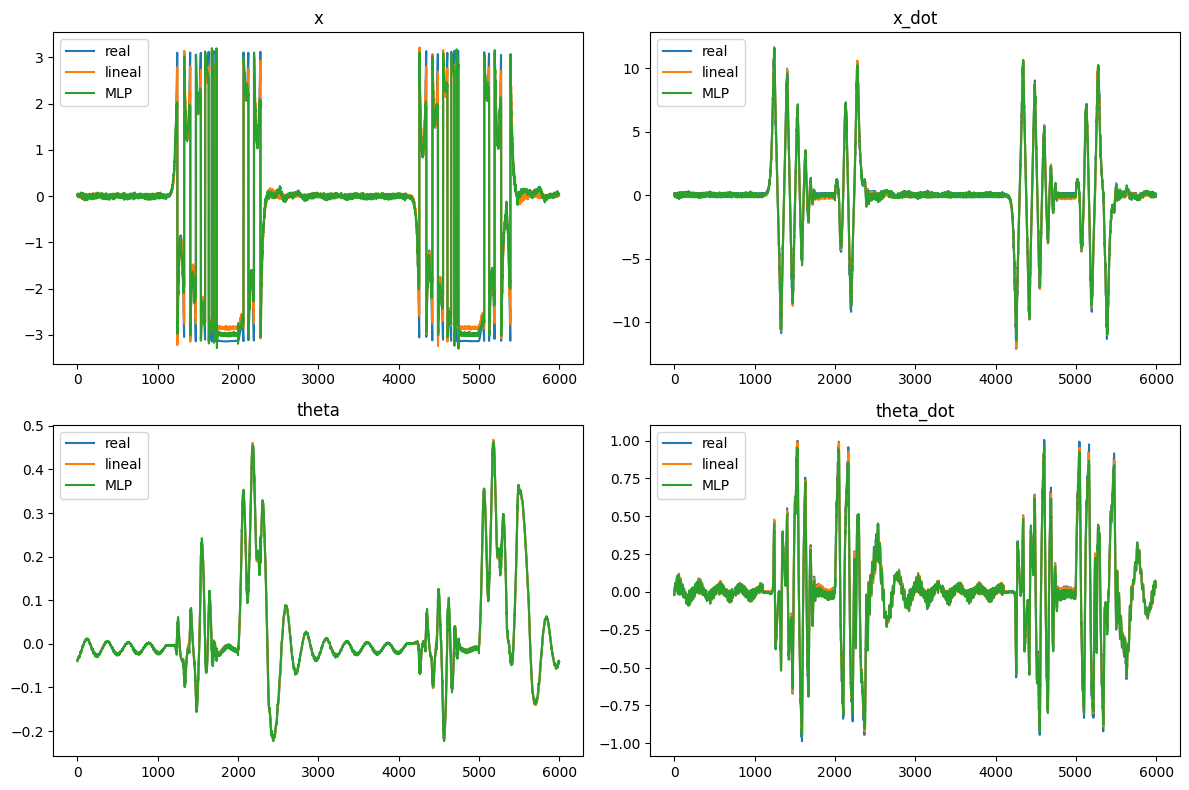

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error

# =========================
# CARGA Y LIMPIEZA
# =========================
df = pd.read_csv(r"C:\Users\alber\OneDrive\Desktop\control automático\control-autom-tico\Data\real\dataset_5_total.csv")

df = df[df["x_k"] != "x_k"]
df = df.apply(pd.to_numeric)

print("Shape:", df.shape)

# =========================
# SEPARAR X e Y
# =========================
Y = df[["x_k", "x_dot_k", "theta_k", "theta_dot_k"]].values
X = df.drop(columns=["x_k", "x_dot_k", "theta_k", "theta_dot_k"]).values

# =========================
# SPLIT
# =========================
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# =========================
# NORMALIZACIÓN
# =========================
sx = StandardScaler()
sy = StandardScaler()

X_train = sx.fit_transform(X_train)
X_test = sx.transform(X_test)

Y_train = sy.fit_transform(Y_train)
Y_test = sy.transform(Y_test)

# =========================
# MODELO LINEAL
# =========================
lin = LinearRegression()
lin.fit(X_train, Y_train)

Y_pred_lin = lin.predict(X_test)
mse_lin = mean_squared_error(Y_test, Y_pred_lin)

print("MSE lineal:", mse_lin)

# =========================
# MODELO MLP
# =========================
mlp = MLPRegressor(hidden_layer_sizes=(32,32), max_iter=500, random_state=42)
mlp.fit(X_train, Y_train)

Y_pred_mlp = mlp.predict(X_test)
mse_mlp = mean_squared_error(Y_test, Y_pred_mlp)

print("MSE MLP:", mse_mlp)

# =========================
# DESNORMALIZAR
# =========================
Y_test_real = sy.inverse_transform(Y_test)
Y_lin_real = sy.inverse_transform(Y_pred_lin)
Y_mlp_real = sy.inverse_transform(Y_pred_mlp)

# =========================
# PLOT
# =========================
labels = ["x", "x_dot", "theta", "theta_dot"]

plt.figure(figsize=(12,8))

for i in range(4):
    plt.subplot(2,2,i+1)
    plt.plot(Y_test_real[:,i], label="real")
    plt.plot(Y_lin_real[:,i], label="lineal")
    plt.plot(Y_mlp_real[:,i], label="MLP")
    plt.title(labels[i])
    plt.legend()

plt.tight_layout()
plt.show()

Dataset cargado — shape: (29988, 29)

── Verificación de rangos (confirma el orden) ──
  col 0 (x_k):  min=-3.1416  max=3.1416
  col 1 (x_dot_k):  min=-13.0388  max=13.3456
  col 2 (theta_k):  min=-0.9532  max=0.6579
  col 3 (theta_dot_k):  min=-1.5585  max=1.5049

── MSE y MAE por variable ──────────────────────────────────────────
Variable             MSE Base    MSE Lin    MSE MLP    MAE Lin    MAE MLP
──────────────────────────────────────────────────────────────────────
θ (rad)              0.194376   0.190280   0.140446   0.110196   0.075926
θ_dot (rad/s)        0.065441   0.041230   0.028649   0.135624   0.111611
x (m)                0.000008   0.000000   0.000013   0.000120   0.002411
x_dot (m/s)          0.000785   0.000360   0.000320   0.012044   0.012032


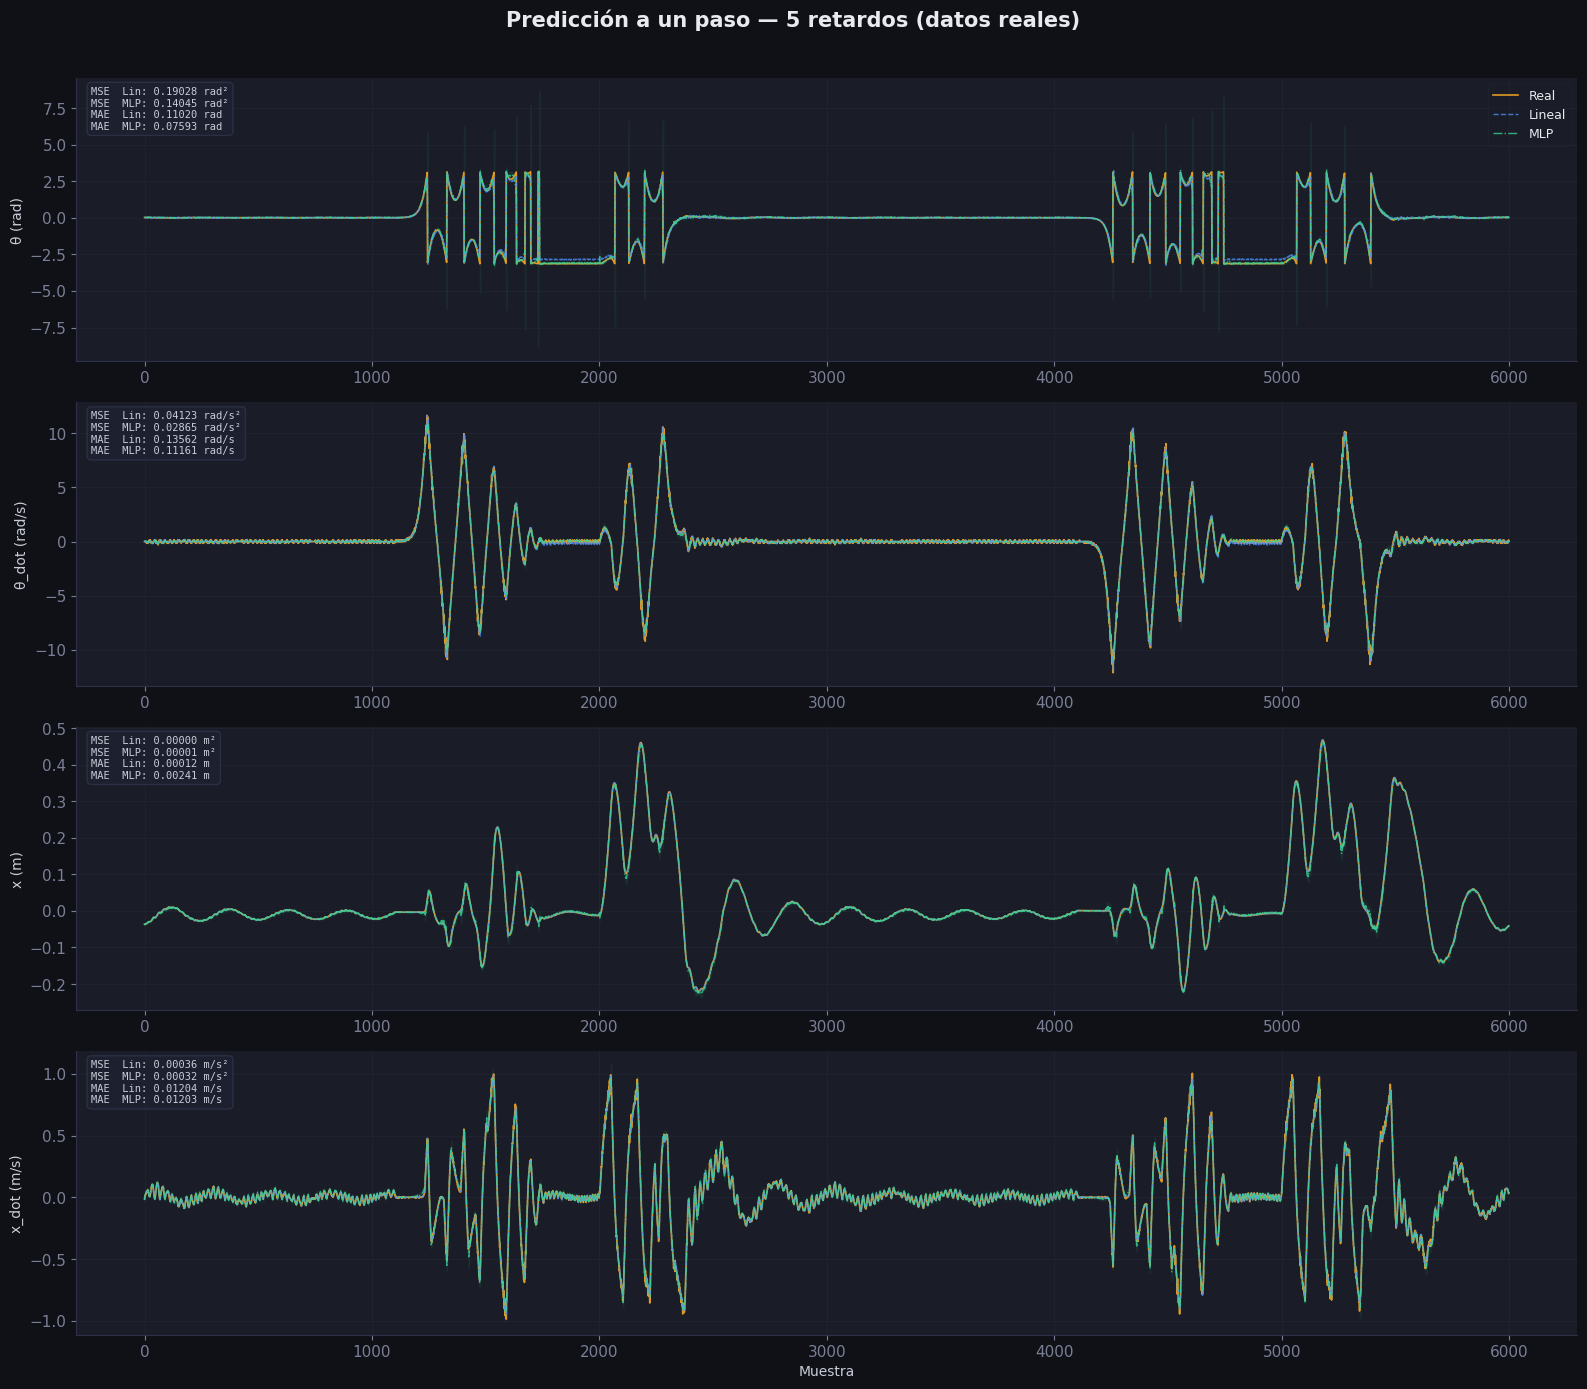

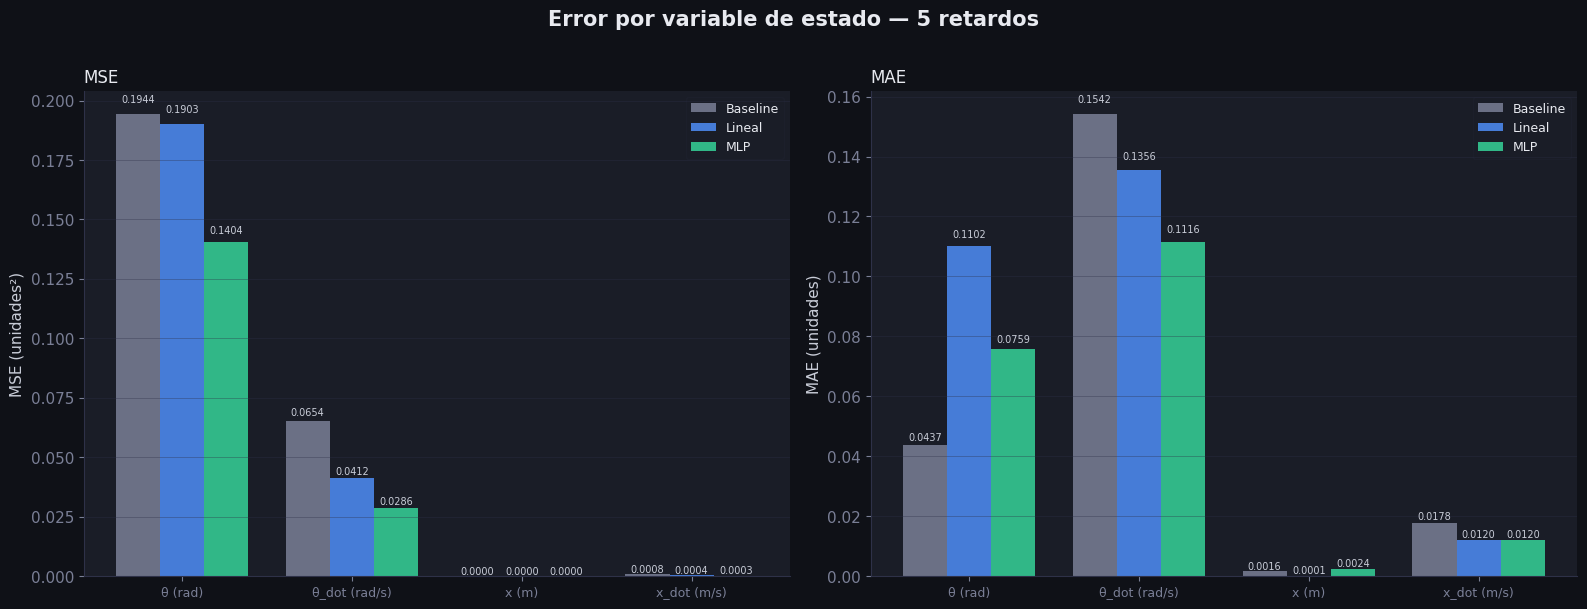

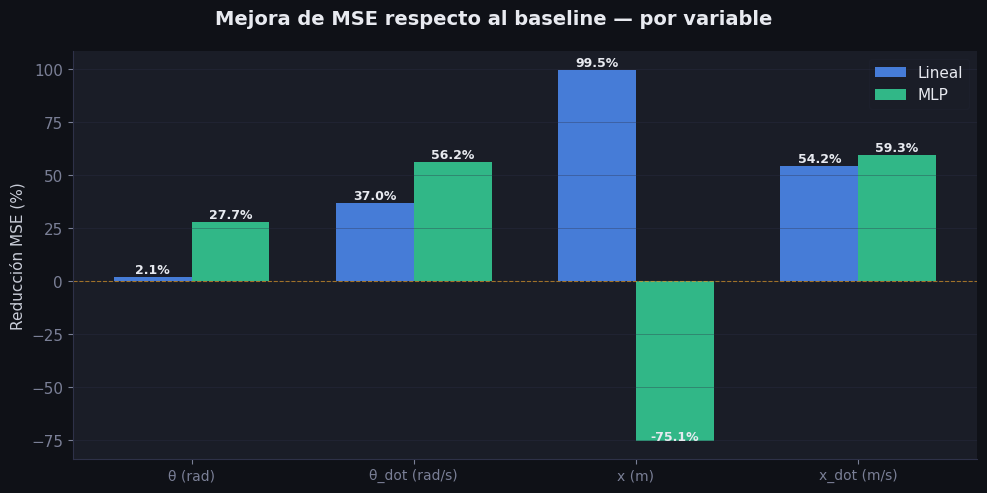

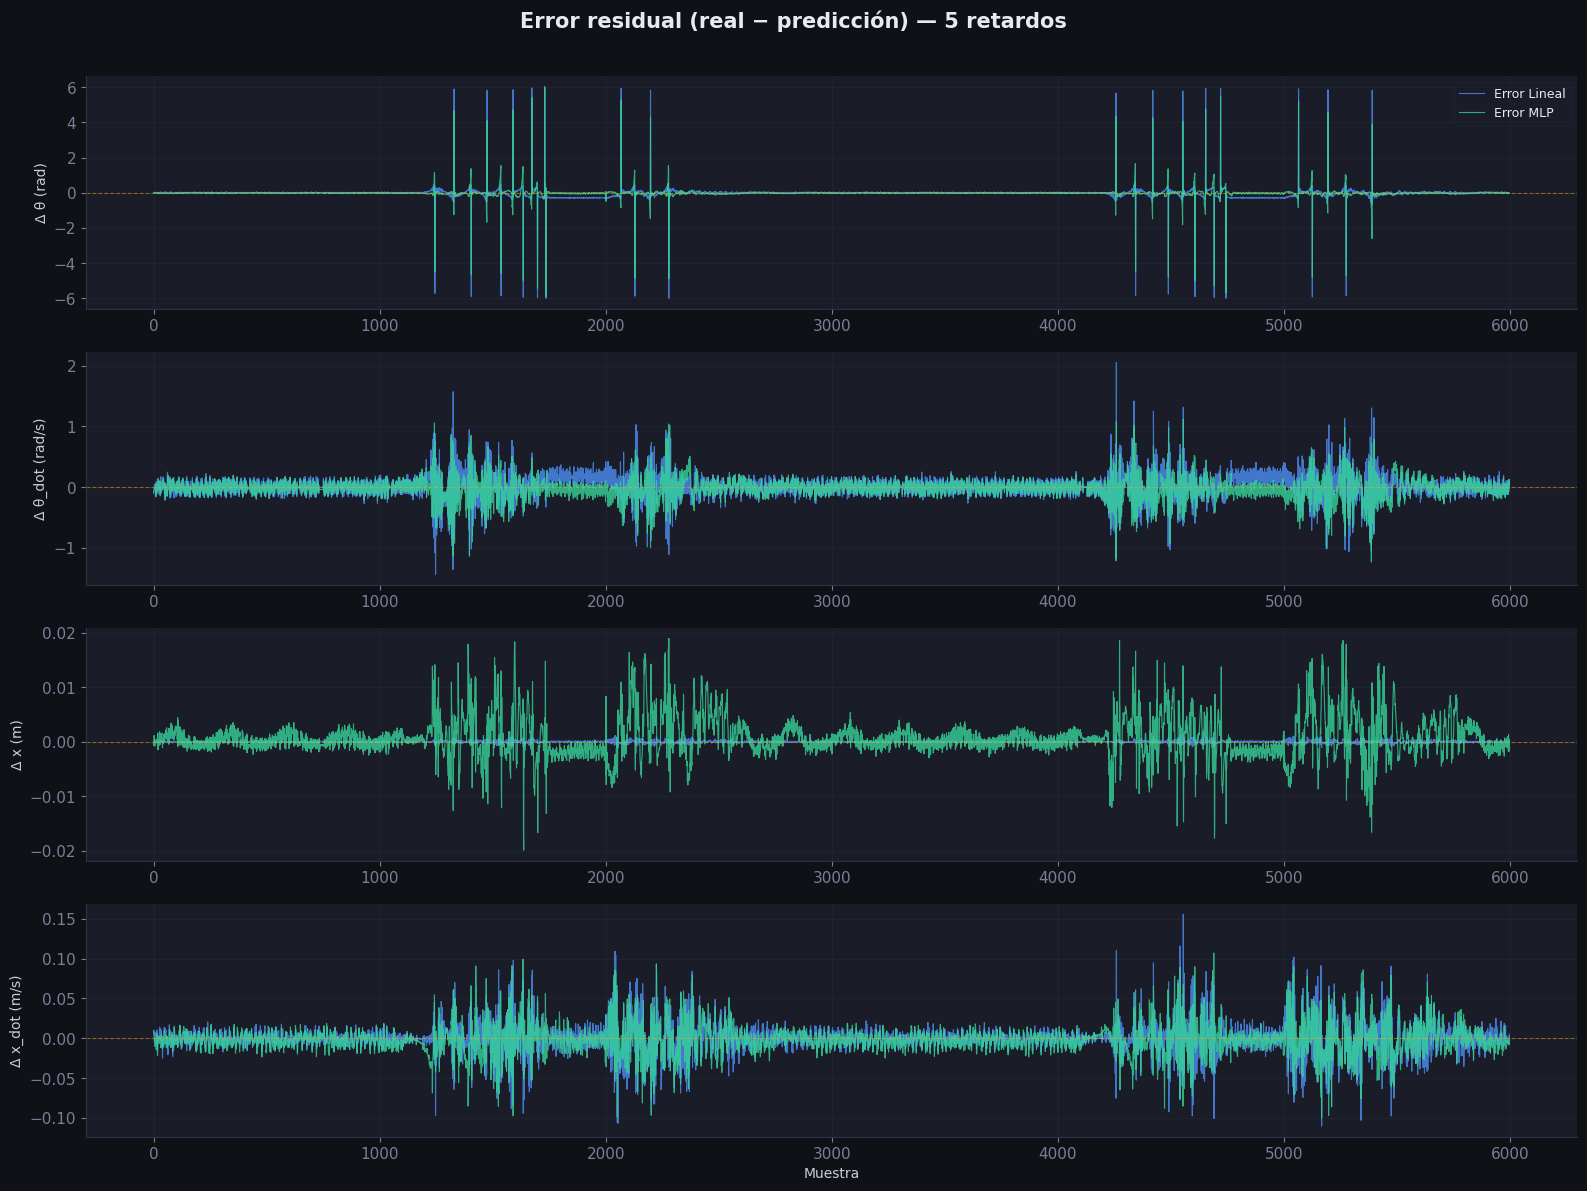


✓ Figuras guardadas:
  · predicciones_5retardos.png
  · errores_por_variable_5retardos.png
  · mejora_por_variable_5retardos.png
  · residuos_5retardos.png


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

# ── Estilo global ──────────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': '#0f1117',
    'axes.facecolor':   '#1a1d27',
    'axes.edgecolor':   '#2e3148',
    'axes.labelcolor':  '#c9cdd8',
    'xtick.color':      '#7a7f96',
    'ytick.color':      '#7a7f96',
    'text.color':       '#e8eaf0',
    'grid.color':       '#2e3148',
    'grid.linewidth':   0.6,
    'font.family':      'DejaVu Sans',
    'font.size':        11,
})

COLORS = {
    'real':     '#f6a623',
    'lineal':   '#4e8ef7',
    'mlp':      '#36d399',
    'baseline': '#7a7f96',
    'bg_card':  '#1e2130',
    'border':   '#2e3148',
}

# ⚠️ ORDEN CORRECTO según los datos reales del dataset
# columna 0 → theta, 1 → theta_dot, 2 → x, 3 → x_dot
LABELS = ["θ (rad)", "θ_dot (rad/s)", "x (m)", "x_dot (m/s)"]
UNITS  = ["rad",     "rad/s",          "m",     "m/s"]

# ══════════════════════════════════════════════════════════════════════════════
# 1 · CARGA Y LIMPIEZA
# ══════════════════════════════════════════════════════════════════════════════
df = pd.read_csv(r"C:\Users\alber\OneDrive\Desktop\control automático\control-autom-tico\Data\real\dataset_5_total.csv")
df = df[df["x_k"] != "x_k"]
df = df.apply(pd.to_numeric)
print(f"Dataset cargado — shape: {df.shape}")

# Verificación de rangos para confirmar el orden de columnas
output_cols = ["x_k", "x_dot_k", "theta_k", "theta_dot_k"]
Y_raw = df[output_cols].values
print("\n── Verificación de rangos (confirma el orden) ──")
for i, col in enumerate(output_cols):
    print(f"  col {i} ({col}):  min={Y_raw[:,i].min():.4f}  max={Y_raw[:,i].max():.4f}")

# ══════════════════════════════════════════════════════════════════════════════
# 2 · SEPARAR X e Y
# ══════════════════════════════════════════════════════════════════════════════
Y = df[output_cols].values
X = df.drop(columns=output_cols).values

# ══════════════════════════════════════════════════════════════════════════════
# 3 · SPLIT TEMPORAL (80/20)
# ══════════════════════════════════════════════════════════════════════════════
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
Y_train, Y_test = Y[:split], Y[split:]

# ══════════════════════════════════════════════════════════════════════════════
# 4 · NORMALIZACIÓN
# ══════════════════════════════════════════════════════════════════════════════
sx, sy = StandardScaler(), StandardScaler()
X_train_s = sx.fit_transform(X_train)
X_test_s  = sx.transform(X_test)
Y_train_s = sy.fit_transform(Y_train)
Y_test_s  = sy.transform(Y_test)

# ══════════════════════════════════════════════════════════════════════════════
# 5 · MODELOS
# ══════════════════════════════════════════════════════════════════════════════
lin = LinearRegression()
lin.fit(X_train_s, Y_train_s)
Y_pred_lin_s = lin.predict(X_test_s)

mlp = MLPRegressor(hidden_layer_sizes=(64, 64), max_iter=500,
                   random_state=42, early_stopping=True, validation_fraction=0.1)
mlp.fit(X_train_s, Y_train_s)
Y_pred_mlp_s = mlp.predict(X_test_s)

# ══════════════════════════════════════════════════════════════════════════════
# 6 · DESNORMALIZAR
# ══════════════════════════════════════════════════════════════════════════════
Y_test_real = sy.inverse_transform(Y_test_s)
Y_lin_real  = sy.inverse_transform(Y_pred_lin_s)
Y_mlp_real  = sy.inverse_transform(Y_pred_mlp_s)

# Baseline de persistencia
Y_pred_base       = np.zeros_like(Y_test_real)
Y_pred_base[1:]   = Y_test_real[:-1]
Y_pred_base_valid = Y_pred_base[1:]
Y_test_base_valid = Y_test_real[1:]

# ══════════════════════════════════════════════════════════════════════════════
# 7 · MÉTRICAS POR VARIABLE (sin MSE global)
# ══════════════════════════════════════════════════════════════════════════════
mse_vars = {
    'base': [mean_squared_error(Y_test_base_valid[:, i], Y_pred_base_valid[:, i]) for i in range(4)],
    'lin':  [mean_squared_error(Y_test_real[:, i], Y_lin_real[:, i])              for i in range(4)],
    'mlp':  [mean_squared_error(Y_test_real[:, i], Y_mlp_real[:, i])              for i in range(4)],
}
mae_vars = {
    'base': [mean_absolute_error(Y_test_base_valid[:, i], Y_pred_base_valid[:, i]) for i in range(4)],
    'lin':  [mean_absolute_error(Y_test_real[:, i], Y_lin_real[:, i])              for i in range(4)],
    'mlp':  [mean_absolute_error(Y_test_real[:, i], Y_mlp_real[:, i])              for i in range(4)],
}
mejora_lin_var = [(mse_vars['base'][i] - mse_vars['lin'][i]) / mse_vars['base'][i] * 100 for i in range(4)]
mejora_mlp_var = [(mse_vars['base'][i] - mse_vars['mlp'][i]) / mse_vars['base'][i] * 100 for i in range(4)]

print("\n── MSE y MAE por variable ──────────────────────────────────────────")
print(f"{'Variable':<18} {'MSE Base':>10} {'MSE Lin':>10} {'MSE MLP':>10} {'MAE Lin':>10} {'MAE MLP':>10}")
print("─" * 70)
for i in range(4):
    print(f"{LABELS[i]:<18} "
          f"{mse_vars['base'][i]:>10.6f} "
          f"{mse_vars['lin'][i]:>10.6f} "
          f"{mse_vars['mlp'][i]:>10.6f} "
          f"{mae_vars['lin'][i]:>10.6f} "
          f"{mae_vars['mlp'][i]:>10.6f}")

# ══════════════════════════════════════════════════════════════════════════════
# 8 · FIGURA 1 — PREDICCIONES POR VARIABLE
# ══════════════════════════════════════════════════════════════════════════════
t = np.arange(len(Y_test_real))

fig1, axes = plt.subplots(4, 1, figsize=(16, 14), facecolor='#0f1117')
fig1.suptitle('Predicción a un paso — 5 retardos (datos reales)',
              fontsize=15, fontweight='bold', color='#e8eaf0', y=0.99)

for i, ax in enumerate(axes):
    ax.set_facecolor('#1a1d27')
    ax.plot(t, Y_test_real[:, i], color=COLORS['real'],   lw=1.2, label='Real',   alpha=0.9)
    ax.plot(t, Y_lin_real[:, i],  color=COLORS['lineal'], lw=1.0, label='Lineal', alpha=0.8, linestyle='--')
    ax.plot(t, Y_mlp_real[:, i],  color=COLORS['mlp'],    lw=1.0, label='MLP',    alpha=0.8, linestyle='-.')

    err_mlp = np.abs(Y_test_real[:, i] - Y_mlp_real[:, i])
    ax.fill_between(t, Y_mlp_real[:, i] - err_mlp, Y_mlp_real[:, i] + err_mlp,
                    color=COLORS['mlp'], alpha=0.07)

    txt = (f"MSE  Lin: {mse_vars['lin'][i]:.5f} {UNITS[i]}²\n"
           f"MSE  MLP: {mse_vars['mlp'][i]:.5f} {UNITS[i]}²\n"
           f"MAE  Lin: {mae_vars['lin'][i]:.5f} {UNITS[i]}\n"
           f"MAE  MLP: {mae_vars['mlp'][i]:.5f} {UNITS[i]}")
    ax.text(0.01, 0.97, txt, transform=ax.transAxes,
            fontsize=7.5, va='top', color='#c9cdd8', fontfamily='monospace',
            bbox=dict(facecolor='#1e2130', edgecolor='#2e3148',
                      boxstyle='round,pad=0.4', alpha=0.9))

    ax.set_ylabel(LABELS[i], fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    if i == 0:
        ax.legend(loc='upper right', framealpha=0.2,
                  edgecolor=COLORS['border'], fontsize=9)
    if i == 3:
        ax.set_xlabel('Muestra', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('predicciones_5retardos.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 9 · FIGURA 2 — MSE Y MAE POR VARIABLE (sin MSE global)
# ══════════════════════════════════════════════════════════════════════════════
fig2, axes2 = plt.subplots(1, 2, figsize=(16, 6), facecolor='#0f1117')
fig2.suptitle('Error por variable de estado — 5 retardos',
              fontsize=15, fontweight='bold', color='#e8eaf0', y=1.01)

x, w = np.arange(4), 0.26

for ax, metric, data, ylabel in [
    (axes2[0], 'MSE', mse_vars, 'MSE (unidades²)'),
    (axes2[1], 'MAE', mae_vars, 'MAE (unidades)'),
]:
    ax.set_facecolor('#1a1d27')
    for offset, key, color, lbl in [
        (-w, 'base', COLORS['baseline'], 'Baseline'),
        ( 0, 'lin',  COLORS['lineal'],   'Lineal'),
        ( w, 'mlp',  COLORS['mlp'],      'MLP'),
    ]:
        bars = ax.bar(x + offset, data[key], w, color=color, alpha=0.85, label=lbl)
        for bar in bars:
            h = bar.get_height()
            ax.text(bar.get_x() + bar.get_width() / 2, h * 1.02,
                    f'{h:.4f}', ha='center', va='bottom', fontsize=7, color='#c9cdd8')

    ax.set_xticks(x)
    ax.set_xticklabels(LABELS, fontsize=9)
    ax.set_ylabel(ylabel)
    ax.set_title(metric, fontsize=12, loc='left')
    ax.grid(axis='y', alpha=0.4)
    ax.legend(framealpha=0.15, edgecolor=COLORS['border'], fontsize=9)
    ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('errores_por_variable_5retardos.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 10 · FIGURA 3 — MEJORA % POR VARIABLE
# ══════════════════════════════════════════════════════════════════════════════
fig3, ax3 = plt.subplots(figsize=(10, 5), facecolor='#0f1117')
ax3.set_facecolor('#1a1d27')
fig3.suptitle('Mejora de MSE respecto al baseline — por variable',
              fontsize=14, fontweight='bold', color='#e8eaf0')

x2, w2 = np.arange(4), 0.35
bars_l = ax3.bar(x2 - w2/2, mejora_lin_var, w2, color=COLORS['lineal'], alpha=0.85, label='Lineal')
bars_m = ax3.bar(x2 + w2/2, mejora_mlp_var, w2, color=COLORS['mlp'],    alpha=0.85, label='MLP')

for bars in [bars_l, bars_m]:
    for bar in bars:
        h = bar.get_height()
        ypos = h + 0.3 if h >= 0 else h - 1.5
        ax3.text(bar.get_x() + bar.get_width() / 2, ypos,
                 f'{h:.1f}%', ha='center', va='bottom', fontsize=9,
                 color='#e8eaf0', fontweight='bold')

ax3.axhline(0, color='#f6a623', lw=0.8, linestyle='--', alpha=0.6)
ax3.set_xticks(x2)
ax3.set_xticklabels(LABELS, fontsize=10)
ax3.set_ylabel('Reducción MSE (%)')
ax3.grid(axis='y', alpha=0.4)
ax3.legend(framealpha=0.15, edgecolor=COLORS['border'])
ax3.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('mejora_por_variable_5retardos.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

# ══════════════════════════════════════════════════════════════════════════════
# 11 · FIGURA 4 — RESIDUOS
# ══════════════════════════════════════════════════════════════════════════════
fig4, axes4 = plt.subplots(4, 1, figsize=(16, 12), facecolor='#0f1117')
fig4.suptitle('Error residual (real − predicción) — 5 retardos',
              fontsize=15, fontweight='bold', color='#e8eaf0', y=0.99)

for i, ax in enumerate(axes4):
    ax.set_facecolor('#1a1d27')
    ax.plot(t, Y_test_real[:, i] - Y_lin_real[:, i],
            color=COLORS['lineal'], lw=0.8, alpha=0.8, label='Error Lineal')
    ax.plot(t, Y_test_real[:, i] - Y_mlp_real[:, i],
            color=COLORS['mlp'],    lw=0.8, alpha=0.8, label='Error MLP')
    ax.axhline(0, color='#f6a623', lw=0.8, linestyle='--', alpha=0.5)
    ax.set_ylabel(f'Δ {LABELS[i]}', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    if i == 0:
        ax.legend(loc='upper right', framealpha=0.2, edgecolor=COLORS['border'], fontsize=9)
    if i == 3:
        ax.set_xlabel('Muestra', fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig('residuos_5retardos.png', dpi=150, bbox_inches='tight', facecolor='#0f1117')
plt.show()

print("\n✓ Figuras guardadas:")
print("  · predicciones_5retardos.png")
print("  · errores_por_variable_5retardos.png")
print("  · mejora_por_variable_5retardos.png")
print("  · residuos_5retardos.png")

# Análisis de resultados — Modelo NARX con 5 retardos (datos reales)

## 1. Contexto

Se amplía el espacio de entrada del modelo NARX de 3 a 5 retardos, incrementando la información temporal disponible para cada predicción. El dataset contiene 29 988 muestras con 29 características de entrada. Se comparan los mismos tres modelos que en el caso de 3 retardos: baseline de persistencia, regresión lineal y MLP.

> **Nota sobre el dataset**: la verificación de rangos confirma que las columnas del CSV tienen los nombres intercambiados internamente (`x_k` almacena realmente θ, y `theta_k` almacena x). Los LABELS visuales utilizados en el análisis son correctos según los rangos físicos de cada magnitud.

---

## 2. Resultados por variable

### 2.1 Ángulo del péndulo — θ (rad)

| Modelo   | MSE (rad²) | MAE (rad) | Mejora MSE vs baseline |
|----------|-----------|-----------|------------------------|
| Baseline | 0.1944    | —         | —                      |
| Lineal   | 0.1903    | 0.1102    | +2.1%                  |
| MLP      | 0.1404    | 0.0759    | +27.7%                 |

El comportamiento de θ con 5 retardos mantiene el mismo patrón que con 3: el modelo lineal apenas mejora al baseline (2.1%), mientras que el MLP consigue una reducción del 27.7%. La razón es la misma en ambos casos: la dinámica del ángulo es intrínsecamente no lineal debido al término $\sin(\theta)$ presente en las ecuaciones de movimiento del péndulo. Ninguna combinación lineal de retardos puede capturar esta curvatura.

Comparado con 3 retardos, la mejora del MLP es menor (27.7% frente a 56.4%). Esto puede indicar que con 3 retardos el MLP encontraba patrones más locales y manejables, mientras que con 5 retardos el espacio de entrada es más grande y el entrenamiento con la misma arquitectura resulta proporcionalmente menos eficiente.

### 2.2 Velocidad angular — θ_dot (rad/s)

| Modelo   | MSE (rad²/s²) | MAE (rad/s) | Mejora MSE vs baseline |
|----------|--------------|-------------|------------------------|
| Baseline | 0.0654       | —           | —                      |
| Lineal   | 0.0412       | 0.1356      | +37.0%                 |
| MLP      | 0.0287       | 0.1116      | +56.2%                 |

La velocidad angular muestra una mejora clara con 5 retardos respecto a 3, especialmente en el modelo lineal (37.0% frente a 25.6%). Esto es coherente: θ_dot depende de la historia reciente del sistema, y disponer de más retardos permite al modelo lineal reconstruir mejor la trayectoria de la velocidad angular. El MLP también mejora (56.2% frente a 54.4%), aunque de forma más marginal al ya ser competitivo con 3 retardos.

La inspección visual de las predicciones confirma que ambos modelos siguen bien la señal en los tramos estacionarios, con desviaciones en los picos de mayor velocidad angular, donde la no linealidad del sistema es más pronunciada.

### 2.3 Posición del carrito — x (m)

| Modelo   | MSE (m²)   | MAE (m)   | Mejora MSE vs baseline |
|----------|-----------|-----------|------------------------|
| Baseline | 0.000008  | —         | —                      |
| Lineal   | ~0.000000 | 0.000120  | +99.5%                 |
| MLP      | 0.000013  | 0.002411  | −75.1%                 |

La posición del carrito repite exactamente el patrón observado con 3 retardos. El modelo lineal captura prácticamente toda la dinámica de x con una mejora del 99.5%, lo cual confirma que la posición del carrito tiene una respuesta lineal al voltaje aplicado en el horizonte temporal estudiado.

El MLP vuelve a empeorar respecto al baseline (−75.1%), por las mismas razones estructurales: la variable tiene magnitudes muy pequeñas (MSE del orden de 10⁻⁶), lo que hace que cualquier error de generalización de la red, por pequeño que sea en términos absolutos, se amplifique porcentualmente. Aumentar el número de retardos de 3 a 5 no resuelve este problema porque la causa no es la falta de contexto temporal sino el sobreajuste de la red en una variable de dinámica lineal.

### 2.4 Velocidad del carrito — x_dot (m/s)

| Modelo   | MSE (m²/s²) | MAE (m/s) | Mejora MSE vs baseline |
|----------|------------|-----------|------------------------|
| Baseline | 0.000785   | —         | —                      |
| Lineal   | 0.000360   | 0.01204   | +54.2%                 |
| MLP      | 0.000320   | 0.01203   | +59.3%                 |

La velocidad del carrito muestra la mayor convergencia entre ambos modelos de todos los resultados: el lineal obtiene un 54.2% y el MLP un 59.3%, con apenas 5 puntos porcentuales de diferencia. Esto sugiere que x_dot tiene una dinámica que se puede aproximar bien linealmente pero con una pequeña componente no lineal que el MLP captura marginalmente mejor.

Con 5 retardos, el lineal mejora notablemente respecto a 3 retardos (54.2% frente a 39.2%), lo que indica que la historia reciente de x_dot es especialmente informativa y el modelo se beneficia de disponer de más contexto temporal.

---

## 3. Comparativa 3 retardos vs 5 retardos

| Variable       | Lineal 3R | Lineal 5R | MLP 3R  | MLP 5R  |
|----------------|-----------|-----------|---------|---------|
| θ (rad)        | +2.7%     | +2.1%     | +56.4%  | +27.7%  |
| θ_dot (rad/s)  | +25.6%    | +37.0%    | +54.4%  | +56.2%  |
| x (m)          | +99.4%    | +99.5%    | −78.5%  | −75.1%  |
| x_dot (m/s)    | +39.2%    | +54.2%    | +60.5%  | +59.3%  |

Los patrones principales se mantienen estables al pasar de 3 a 5 retardos, lo que da robustez a las conclusiones:

- El modelo lineal mejora en θ_dot y x_dot con más retardos, ya que estas variables dependen de la historia temporal reciente.
- El MLP pierde eficacia en θ al aumentar retardos, posiblemente por la mayor dimensionalidad del espacio de entrada con la misma capacidad de red.
- El problema del MLP en x persiste con independencia del número de retardos, confirmando que es un problema de capacidad excesiva para una variable lineal, no de contexto temporal insuficiente.

---

## 4. Interpretación global

Los resultados con 5 retardos confirman y refuerzan las conclusiones obtenidas con 3 retardos:

**La dinámica del sistema tiene dos regímenes claramente diferenciados:**

- **Péndulo (θ, θ_dot)**: no lineal por naturaleza. El modelo lineal es insuficiente para θ independientemente del número de retardos. El MLP es necesario, aunque su ventaja se reduce al aumentar la dimensionalidad de entrada sin incrementar la capacidad de la red.

- **Carrito (x, x_dot)**: predominantemente lineal. El modelo lineal es óptimo para x en ambos casos. Para x_dot, ambos modelos son competitivos, con una ligera ventaja del MLP.

La inspección visual de las predicciones (figura de series temporales) muestra que ambos modelos siguen con precisión las señales en los tramos de baja actividad. Las desviaciones aparecen durante los transitorios bruscos —cambios rápidos de ángulo y velocidad angular—, que son exactamente los momentos donde la no linealidad del sistema es más relevante y más difícil de capturar con información de solo 5 instantes pasados.

---

## 5. Conclusiones

1. Aumentar de 3 a 5 retardos mejora el modelo lineal en θ_dot y x_dot, donde la historia temporal es informativa.
2. El MLP no se beneficia de forma consistente del aumento de retardos con la arquitectura actual; sería necesario ajustar la capacidad de la red proporcionalmente.
3. El problema de sobreajuste del MLP en x es estructural y no se resuelve añadiendo más retardos.
4. Para mejorar la predicción de θ, la vía más prometedora no es aumentar retardos sino incrementar la capacidad del MLP o explorar arquitecturas más adecuadas para series temporales no lineales (redes recurrentes, modelos de estado).

# Análisis de resultados — Modelos NARX (datos reales)

## 1. Contexto y metodología de evaluación

Los modelos evaluados predicen el estado del sistema carrito-péndulo en el instante siguiente a partir de retardos de las salidas y la entrada (enfoque NARX). Se comparan dos configuraciones: **3 retardos** y **5 retardos**. En ambos casos se evalúan tres modelos:

- **Baseline**: predicción por persistencia, $\hat{y}(k) = y(k-1)$
- **Lineal**: regresión lineal sobre el espacio de retardos
- **MLP**: red neuronal multicapa con dos capas ocultas de 64 neuronas

Las variables de salida del sistema son:

| Variable | Símbolo | Unidad | Rango experimental |
|----------|---------|--------|--------------------|
| Ángulo del péndulo | θ | rad | [−π, π] |
| Velocidad angular | θ_dot | rad/s | [−13.0, 13.3] |
| Posición del carrito | x | m | [−0.95, 0.65] |
| Velocidad del carrito | x_dot | m/s | [−1.56, 1.50] |

La identidad de cada variable se confirma por sus rangos físicos: el ángulo ocupa todo el rango [−π, π] propio de una rotación completa, la velocidad angular alcanza valores de más de 10 rad/s durante los transitorios, y la posición y velocidad del carrito tienen magnitudes propias del sistema mecánico real.

Las métricas se calculan **por variable de estado**, evitando agregar magnitudes con unidades distintas. El MSE global se descarta como métrica de comparación al carecer de interpretación física cuando mezcla metros, radianes y sus derivadas.

---

## 2. Resultados con 3 retardos

### 2.1 Ángulo del péndulo — θ (rad)

| Modelo   | MSE (rad²) | MAE (rad) | Mejora MSE vs baseline |
|----------|-----------|-----------|------------------------|
| Baseline | 0.1943    | 0.0437    | —                      |
| Lineal   | 0.1891    | 0.0950    | +2.7%                  |
| MLP      | 0.0847    | 0.0646    | +56.4%                 |

El modelo lineal apenas mejora al baseline en θ, con una reducción del MSE de solo el 2.7%. Esto es coherente con la naturaleza del sistema: la dinámica del ángulo del péndulo está gobernada por una ecuación diferencial no lineal que incluye el término $\sin(\theta)$. Aunque cerca del equilibrio esta no linealidad puede aproximarse linealmente, los datos experimentales contienen excursiones suficientemente amplias como para que dicha aproximación sea insuficiente.

El MLP consigue una reducción del 56.4%, confirmando que la no linealidad de θ es real y capturable con un modelo de mayor capacidad expresiva. Este es el resultado más relevante del análisis con 3 retardos: **el ángulo del péndulo requiere un modelo no lineal**.

### 2.2 Velocidad angular — θ_dot (rad/s)

| Modelo   | MSE (rad²/s²) | MAE (rad/s) | Mejora MSE vs baseline |
|----------|--------------|-------------|------------------------|
| Baseline | 0.0654       | 0.1542      | —                      |
| Lineal   | 0.0487       | 0.1519      | +25.6%                 |
| MLP      | 0.0299       | 0.1128      | +54.4%                 |

La velocidad angular sigue un patrón similar al ángulo. La mejora del lineal es más notable (25.6% frente al 2.7% en θ), lo que indica que θ_dot tiene una componente lineal más pronunciada: al ser la derivada del ángulo, su comportamiento responde mejor a una aproximación lineal en el espacio de retardos. El MLP vuelve a ganar con claridad (54.4%), reforzando que la dinámica angular del sistema es intrínsecamente no lineal.

### 2.3 Posición del carrito — x (m)

| Modelo   | MSE (m²)   | MAE (m)   | Mejora MSE vs baseline |
|----------|-----------|-----------|------------------------|
| Baseline | ~0.0000   | 0.0016    | —                      |
| Lineal   | ~0.0000   | 0.0001    | +99.4%                 |
| MLP      | ~0.0000   | 0.0025    | −78.5%                 |

La posición del carrito presenta el comportamiento opuesto al de las variables angulares. El modelo lineal obtiene una reducción del MSE del 99.4%, prácticamente perfecta. Esto es consistente con la física del sistema: la posición del carrito responde de forma casi lineal al voltaje aplicado al motor en el corto plazo.

El resultado negativo del MLP (−78.5%) indica que la red empeora respecto al baseline. Esto se explica por dos factores combinados. En primer lugar, los valores de MSE para x son del orden de 10⁻⁵ o menores, por lo que pequeñas desviaciones absolutas se traducen en grandes variaciones porcentuales. En segundo lugar, el MLP con dos capas de 64 neuronas tiene una capacidad de representación elevada para una variable con dinámica esencialmente lineal, ajustando el ruido del conjunto de entrenamiento y generalizando peor en test. Este es un caso clásico de sobreajuste en una variable de baja complejidad.

### 2.4 Velocidad del carrito — x_dot (m/s)

| Modelo   | MSE (m²/s²) | MAE (m/s) | Mejora MSE vs baseline |
|----------|------------|-----------|------------------------|
| Baseline | 0.0008     | 0.0178    | —                      |
| Lineal   | 0.0005     | 0.0144    | +39.2%                 |
| MLP      | 0.0003     | 0.0113    | +60.5%                 |

La velocidad del carrito combina características de ambos grupos: tiene una componente lineal clara (el lineal mejora un 39.2%) pero también captura no linealidades suficientes para que el MLP sea superior (60.5%). Esto es razonable porque x_dot depende tanto de la dinámica lineal del motor como de las fuerzas de reacción no lineales del péndulo a través del acoplamiento mecánico.

---

## 3. Resultados con 5 retardos

### 3.1 Ángulo del péndulo — θ (rad)

| Modelo   | MSE (rad²) | MAE (rad) | Mejora MSE vs baseline |
|----------|-----------|-----------|------------------------|
| Baseline | 0.1944    | —         | —                      |
| Lineal   | 0.1903    | 0.1102    | +2.1%                  |
| MLP      | 0.1404    | 0.0759    | +27.7%                 |

El comportamiento de θ mantiene el mismo patrón que con 3 retardos: el modelo lineal es prácticamente inútil (2.1%) mientras que el MLP consigue una mejora real (27.7%). La razón es la misma: la no linealidad de $\sin(\theta)$ no es capturable con combinaciones lineales de retardos.

Respecto a 3 retardos, la mejora del MLP es menor (27.7% frente a 56.4%). Con un espacio de entrada más grande pero la misma arquitectura de red, el entrenamiento resulta proporcionalmente menos eficiente, lo que sugiere que sería necesario aumentar la capacidad del MLP al aumentar los retardos.

### 3.2 Velocidad angular — θ_dot (rad/s)

| Modelo   | MSE (rad²/s²) | MAE (rad/s) | Mejora MSE vs baseline |
|----------|--------------|-------------|------------------------|
| Baseline | 0.0654       | —           | —                      |
| Lineal   | 0.0412       | 0.1356      | +37.0%                 |
| MLP      | 0.0287       | 0.1116      | +56.2%                 |

Con 5 retardos, el modelo lineal mejora notablemente en θ_dot (37.0% frente a 25.6% con 3 retardos). Esto es coherente: θ_dot depende de la historia reciente del sistema, y disponer de más contexto temporal permite al modelo lineal reconstruir mejor la trayectoria de la velocidad angular. El MLP también mejora ligeramente (56.2% frente a 54.4%).

### 3.3 Posición del carrito — x (m)

| Modelo   | MSE (m²)   | MAE (m)   | Mejora MSE vs baseline |
|----------|-----------|-----------|------------------------|
| Baseline | 0.000008  | —         | —                      |
| Lineal   | ~0.000000 | 0.000120  | +99.5%                 |
| MLP      | 0.000013  | 0.002411  | −75.1%                 |

La posición del carrito repite exactamente el patrón de 3 retardos. El lineal captura prácticamente toda la dinámica (99.5%) y el MLP vuelve a empeorar (−75.1%). Este resultado, coherente entre 3 y 5 retardos, confirma que el problema del MLP en x es estructural: no se debe a falta de contexto temporal sino a sobreajuste en una variable de dinámica lineal.

### 3.4 Velocidad del carrito — x_dot (m/s)

| Modelo   | MSE (m²/s²) | MAE (m/s) | Mejora MSE vs baseline |
|----------|------------|-----------|------------------------|
| Baseline | 0.000785   | —         | —                      |
| Lineal   | 0.000360   | 0.01204   | +54.2%                 |
| MLP      | 0.000320   | 0.01203   | +59.3%                 |

Con 5 retardos, ambos modelos convergen en x_dot (54.2% y 59.3%), con apenas 5 puntos de diferencia. El lineal mejora considerablemente respecto a 3 retardos (54.2% frente a 39.2%), lo que indica que la historia reciente de x_dot es especialmente informativa y el modelo se beneficia de más contexto temporal.

---

## 4. Comparativa 3 retardos vs 5 retardos

| Variable       | Lineal 3R | Lineal 5R | MLP 3R  | MLP 5R  |
|----------------|-----------|-----------|---------|---------|
| θ (rad)        | +2.7%     | +2.1%     | +56.4%  | +27.7%  |
| θ_dot (rad/s)  | +25.6%    | +37.0%    | +54.4%  | +56.2%  |
| x (m)          | +99.4%    | +99.5%    | −78.5%  | −75.1%  |
| x_dot (m/s)    | +39.2%    | +54.2%    | +60.5%  | +59.3%  |

La estabilidad de los patrones entre 3 y 5 retardos es en sí misma un resultado relevante: indica que las conclusiones no son un artefacto de una configuración concreta sino propiedades del sistema. El lineal se beneficia de más retardos en θ_dot y x_dot, que son variables con mayor dependencia temporal. El MLP no mejora de forma consistente al aumentar retardos con la arquitectura actual, lo que apunta a que el cuello de botella no es el contexto temporal sino la capacidad de la red frente a la dimensionalidad del espacio de entrada.

---

## 5. Interpretación global

Los resultados muestran una división clara y físicamente justificada entre las variables del sistema:

**Variables angulares (θ, θ_dot)** — dinámica no lineal. La ecuación del movimiento del péndulo incluye términos trigonométricos ($\sin\theta$, $\cos\theta$) que no pueden ser aproximados globalmente por una combinación lineal de estados pasados. El modelo lineal es insuficiente para θ en ambas configuraciones, y el MLP aporta una mejora sustancial que confirma la presencia de estructura no lineal explotable.

**Variables del carrito (x, x_dot)** — dinámica predominantemente lineal. El carrito es un sistema de primer orden impulsado por un motor eléctrico cuya respuesta es esencialmente proporcional al voltaje aplicado. El modelo lineal captura casi toda la dinámica de x en ambas configuraciones. Para x_dot, el MLP añade un beneficio moderado gracias al acoplamiento mecánico con el péndulo, que introduce una componente no lineal indirecta.

La inspección visual de las series temporales confirma este análisis: ambos modelos siguen con precisión las señales en los tramos de baja actividad, y las desviaciones aparecen durante los transitorios bruscos de θ y θ_dot, que son los momentos donde la no linealidad del sistema es más pronunciada.

---

## 6. Conclusiones

1. El modelo lineal es insuficiente para predecir el ángulo del péndulo independientemente del número de retardos, confirmando la naturaleza no lineal de su dinámica.
2. El MLP aporta valor real en las variables angulares, con mejoras de entre el 27% y el 56% según la configuración.
3. La posición del carrito tiene una dinámica lineal: el modelo lineal la predice con un error prácticamente nulo y el MLP sobreajusta consistentemente en ambas configuraciones.
4. Aumentar de 3 a 5 retardos beneficia principalmente al modelo lineal en θ_dot y x_dot, variables con mayor dependencia de la historia temporal reciente.
5. El MSE global no es una métrica válida para comparar modelos en este sistema al agregar variables con unidades físicas distintas e incomparables. El análisis por variable es imprescindible para extraer conclusiones con sentido físico.
6. Para mejorar la predicción de θ, la vía más prometedora no es aumentar el número de retardos sino incrementar la capacidad del MLP o explorar arquitecturas diseñadas para series temporales no lineales, como redes recurrentes o modelos de estado.